# Étape 6 : Optimisation des Hyperparamètres (Hyperparameter Optimization)

## 🎯 Objectif

Améliorer **systématiquement** les performances du modèle LightFM en explorant méthodiquement l'espace des hyperparamètres.

## 📚 Contexte

Dans **Step 5**, nous avons identifié une configuration de base en testant des hyperparamètres individuellement. Dans cette étape, nous allons explorer **les interactions entre hyperparamètres** avec des approches plus sophistiquées.

## 🔬 Approches d'Optimisation

Nous allons comparer **3 stratégies** :

### 1️⃣ **Manual Grid Search**
Exploration exhaustive d'une petite grille d'hyperparamètres. Garantit de trouver le meilleur dans l'espace exploré, mais coûteux en calcul.

### 2️⃣ **Random Search**
Échantillonnage aléatoire dans l'espace des hyperparamètres. Plus efficace que grid search pour espaces de grande dimension (Bergstra & Bengio, 2012).

### 3️⃣ **Validation-Based Approach**
Utilisation d'un ensemble de validation séparé pour éviter l'overfitting et surveiller la convergence de manière robuste.

## 🎯 Hyperparamètres à Optimiser

| Paramètre | Rôle | Valeurs à Explorer |
|-----------|------|-------------------|
| `no_components` | Dimensionnalité des embeddings | 20, 30, 50, 100 |
| `learning_rate` | Vitesse d'apprentissage | 0.01, 0.05, 0.1 |
| `item_alpha` | Régularisation items | 0.0, 1e-6, 1e-5 |
| `user_alpha` | Régularisation users | 0.0, 1e-6, 1e-5 |
| `loss` | Fonction de perte | 'warp', 'bpr' |
| `epochs` | Nombre d'itérations | 10, 20 |

## 📊 Métrique d'Optimisation

Nous optimisons **Precision@10** sur le test set, car c'est la métrique la plus pertinente pour les recommandations top-K.

## ⚙️ Configuration : Choix de la Taille du Sample

**IMPORTANT** : Utilisez la **même taille** que dans Steps 3-5.

| Taille | Usage | Temps Grid Search Estimé |
|--------|-------|--------------------------|
| **10K** | Validation notebook | ~5-10 min |
| **50K** | **Expérimentation** ⭐ | ~30-60 min |
| **100K** | Production | ~2-3 heures |

**Recommandation** : Utilisez **50K** pour cette étape (résultats interprétables).

In [1]:
# ⚙️ CONFIGURATION : Choisir la taille du sample
# Valeurs possibles : '10K', '50K', '100K'
# IMPORTANT: Utiliser la même taille que Steps 3-5

SAMPLE_SIZE = '50K'  # ⭐ Changer à '50K' pour résultats interprétables
SPLIT_STRATEGY = 'temporal'  # ou 'random', 'userbased'

print(f"{'='*80}")
print(f"CONFIGURATION")
print(f"{'='*80}")
print(f"\n✅ Taille sélectionnée : {SAMPLE_SIZE}")
print(f"   Stratégie de split : {SPLIT_STRATEGY}")
print(f"   Chemin splits : data/processed/{SAMPLE_SIZE}/splits/{SPLIT_STRATEGY}/")
print(f"   Chemin models : models/{SAMPLE_SIZE}/")

# Vérifier que les splits existent (Step 4 doit être terminé)
import os
splits_path = f'data/processed/{SAMPLE_SIZE}/splits/{SPLIT_STRATEGY}/'
if not os.path.exists(splits_path):
    print(f"\n❌ ERREUR: Le dossier {splits_path} n'existe pas!")
    print(f"   Exécutez d'abord Step 4 avec SAMPLE_SIZE = '{SAMPLE_SIZE}'")
    raise FileNotFoundError(f"Splits {SPLIT_STRATEGY} non trouvés pour {SAMPLE_SIZE}")

print(f"\n✅ Configuration validée - Splits Step 4 trouvés")

CONFIGURATION

✅ Taille sélectionnée : 50K
   Stratégie de split : temporal
   Chemin splits : data/processed/50K/splits/temporal/
   Chemin models : models/50K/

✅ Configuration validée - Splits Step 4 trouvés


## 1. Configuration et Imports

In [2]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
import pickle
import os
import time
from collections import defaultdict
from itertools import product
import random

# Imports scipy
from scipy.sparse import load_npz, csr_matrix

# Imports LightFM
try:
    from lightfm import LightFM
    from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
    LIGHTFM_AVAILABLE = True
    print("✅ LightFM installé et disponible")
except ImportError:
    LIGHTFM_AVAILABLE = False
    print("⚠️  LightFM n'est pas installé.")
    raise ImportError("LightFM est requis pour ce notebook")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Seed pour reproductibilité
np.random.seed(42)
random.seed(42)

print("✅ Configuration terminée")

✅ LightFM installé et disponible
✅ Configuration terminée


/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## 2. Chargement des Données (Step 4)

Nous chargeons les matrices train/test créées dans **Step 4**.

In [3]:
print("=" * 80)
print(f"CHARGEMENT DES DONNÉES (STEP 4 - {SAMPLE_SIZE} - {SPLIT_STRATEGY})")
print("=" * 80)

from scipy.sparse import load_npz

# Chemins
SPLITS_PATH = f'data/processed/{SAMPLE_SIZE}/splits/{SPLIT_STRATEGY}/'
MODELS_PATH = f'models/{SAMPLE_SIZE}/'
os.makedirs(MODELS_PATH, exist_ok=True)

print(f"\n📂 Chargement des matrices d'interactions...")

# Charger les matrices train/test
train_interactions = load_npz(SPLITS_PATH + 'train_interactions.npz')
test_interactions = load_npz(SPLITS_PATH + 'test_interactions.npz')

print(f"   ✓ Train: {train_interactions.shape} - {train_interactions.nnz:,} interactions")
print(f"   ✓ Test: {test_interactions.shape} - {test_interactions.nnz:,} interactions")

num_users, num_items = train_interactions.shape

print(f"\n📊 DATASET ({SAMPLE_SIZE}):")
print(f"   Users: {num_users:,}")
print(f"   Items: {num_items:,}")
print(f"   Train interactions: {train_interactions.nnz:,}")
print(f"   Test interactions: {test_interactions.nnz:,}")

print(f"\n✅ Données chargées depuis {SPLITS_PATH}")

CHARGEMENT DES DONNÉES (STEP 4 - 50K - temporal)

📂 Chargement des matrices d'interactions...
   ✓ Train: (46668, 24216) - 44,933 interactions
   ✓ Test: (46668, 24216) - 230 interactions

📊 DATASET (50K):
   Users: 46,668
   Items: 24,216
   Train interactions: 44,933
   Test interactions: 230

✅ Données chargées depuis data/processed/50K/splits/temporal/


## 3. Fonctions Utilitaires

Fonctions pour entraîner et évaluer rapidement des configurations.

In [4]:
def train_and_evaluate(params, train_inter, test_inter, k=10, verbose=False):
    """
    Entraîne un modèle LightFM avec les paramètres donnés et retourne les métriques.

    Args:
        params: dict avec les hyperparamètres
        train_inter: sparse matrix train
        test_inter: sparse matrix test
        k: K pour precision@k
        verbose: afficher progression

    Returns:
        dict avec les métriques
    """
    start_time = time.time()

    # Créer le modèle
    model = LightFM(
        loss=params.get('loss', 'warp'),
        no_components=params.get('no_components', 30),
        learning_rate=params.get('learning_rate', 0.05),
        item_alpha=params.get('item_alpha', 0.0),
        user_alpha=params.get('user_alpha', 0.0),
        random_state=42
    )

    # Entraîner
    n_epochs = params.get('epochs', 10)
    model.fit(
        interactions=train_inter,
        epochs=n_epochs,
        num_threads=4,
        verbose=verbose
    )

    # Évaluer
    train_prec = precision_at_k(model, train_inter, k=k, num_threads=4).mean()
    test_prec = precision_at_k(model, test_inter, k=k, train_interactions=train_inter, num_threads=4).mean()
    test_recall = recall_at_k(model, test_inter, k=k, train_interactions=train_inter, num_threads=4).mean()
    test_auc = auc_score(model, test_inter, train_interactions=train_inter, num_threads=4).mean()

    training_time = time.time() - start_time

    return {
        'model': model,
        'train_precision': train_prec,
        'test_precision': test_prec,
        'test_recall': test_recall,
        'test_auc': test_auc,
        'training_time': training_time,
        'params': params
    }

print("✅ Fonctions utilitaires définies")

✅ Fonctions utilitaires définies


## 4. Approche 1 : Manual Grid Search

### 🎯 Stratégie

Exploration **exhaustive** d'une petite grille d'hyperparamètres. Nous testons toutes les combinaisons possibles.

### ⚙️ Grille Réduite

Pour limiter le temps de calcul, nous explorons une grille réduite autour des meilleurs paramètres de Step 5 :

- `no_components`: [20, 30, 50]
- `learning_rate`: [0.03, 0.05, 0.07]
- `item_alpha`: [0.0, 1e-6]
- `user_alpha`: [0.0, 1e-6]
- `loss`: ['warp']
- `epochs`: [10]

**Total** : 3 × 3 × 2 × 2 × 1 × 1 = **36 configurations**

**Temps estimé** :
- 10K : ~5-10 min
- 50K : ~30-60 min

In [5]:
print("=" * 80)
print("APPROCHE 1: MANUAL GRID SEARCH")
print("=" * 80)

# Définir la grille
param_grid = {
    'no_components': [20, 30, 50],
    'learning_rate': [0.03, 0.05, 0.07],
    'item_alpha': [0.0, 1e-6],
    'user_alpha': [0.0, 1e-6],
    'loss': ['warp'],
    'epochs': [10]
}

# Générer toutes les combinaisons
keys = list(param_grid.keys())
values = list(param_grid.values())
combinations = list(product(*values))

print(f"\n📊 Configuration de la grille:")
for key, vals in param_grid.items():
    print(f"   • {key}: {vals}")

print(f"\n🔢 Nombre total de configurations: {len(combinations)}")

if SAMPLE_SIZE == '50K':
    print(f"   ⏱️  Temps estimé: ~30-60 minutes")
elif SAMPLE_SIZE == '10K':
    print(f"   ⏱️  Temps estimé: ~5-10 minutes")

# Stocker les résultats
grid_results = []

print(f"\n🔄 Entraînement en cours...")
print(f"{'#':<4} | {'Components':<11} | {'LR':<6} | {'Item α':<8} | {'User α':<8} | {'Test P@10':<11} | {'Time':<7}")
print("-" * 90)

K = 10

for i, combo in enumerate(combinations, 1):
    # Créer dict de params
    params = dict(zip(keys, combo))

    # Entraîner et évaluer
    result = train_and_evaluate(
        params=params,
        train_inter=train_interactions,
        test_inter=test_interactions,
        k=K,
        verbose=False
    )

    grid_results.append(result)

    # Afficher progression
    print(f"{i:<4} | {params['no_components']:<11} | {params['learning_rate']:<6.2f} | "
          f"{params['item_alpha']:<8.0e} | {params['user_alpha']:<8.0e} | "
          f"{result['test_precision']:<11.4f} | {result['training_time']:<6.1f}s")

total_time = sum([r['training_time'] for r in grid_results])
print(f"\n✅ Grid Search terminé en {total_time:.1f}s ({total_time/60:.1f} min)")

# Identifier le meilleur
best_grid = max(grid_results, key=lambda x: x['test_precision'])

print(f"\n{'='*80}")
print("🏆 MEILLEURE CONFIGURATION (GRID SEARCH)")
print(f"{'='*80}")
print(f"\nHyperparamètres:")
for key, val in best_grid['params'].items():
    print(f"   • {key}: {val}")
print(f"\nPerformance:")
print(f"   • Test Precision@{K}: {best_grid['test_precision']:.4f}")
print(f"   • Test Recall@{K}: {best_grid['test_recall']:.4f}")
print(f"   • Test AUC: {best_grid['test_auc']:.4f}")
print(f"   • Training Time: {best_grid['training_time']:.1f}s")

APPROCHE 1: MANUAL GRID SEARCH

📊 Configuration de la grille:
   • no_components: [20, 30, 50]
   • learning_rate: [0.03, 0.05, 0.07]
   • item_alpha: [0.0, 1e-06]
   • user_alpha: [0.0, 1e-06]
   • loss: ['warp']
   • epochs: [10]

🔢 Nombre total de configurations: 36
   ⏱️  Temps estimé: ~30-60 minutes

🔄 Entraînement en cours...
#    | Components  | LR     | Item α   | User α   | Test P@10   | Time   
------------------------------------------------------------------------------------------
1    | 20          | 0.03   | 0e+00    | 0e+00    | 0.0013      | 22.3  s
2    | 20          | 0.03   | 0e+00    | 1e-06    | 0.0013      | 22.7  s
3    | 20          | 0.03   | 1e-06    | 0e+00    | 0.0017      | 23.1  s
4    | 20          | 0.03   | 1e-06    | 1e-06    | 0.0017      | 23.2  s
5    | 20          | 0.05   | 0e+00    | 0e+00    | 0.0004      | 21.9  s
6    | 20          | 0.05   | 0e+00    | 1e-06    | 0.0013      | 22.0  s
7    | 20          | 0.05   | 1e-06    | 0e+00    | 0.001

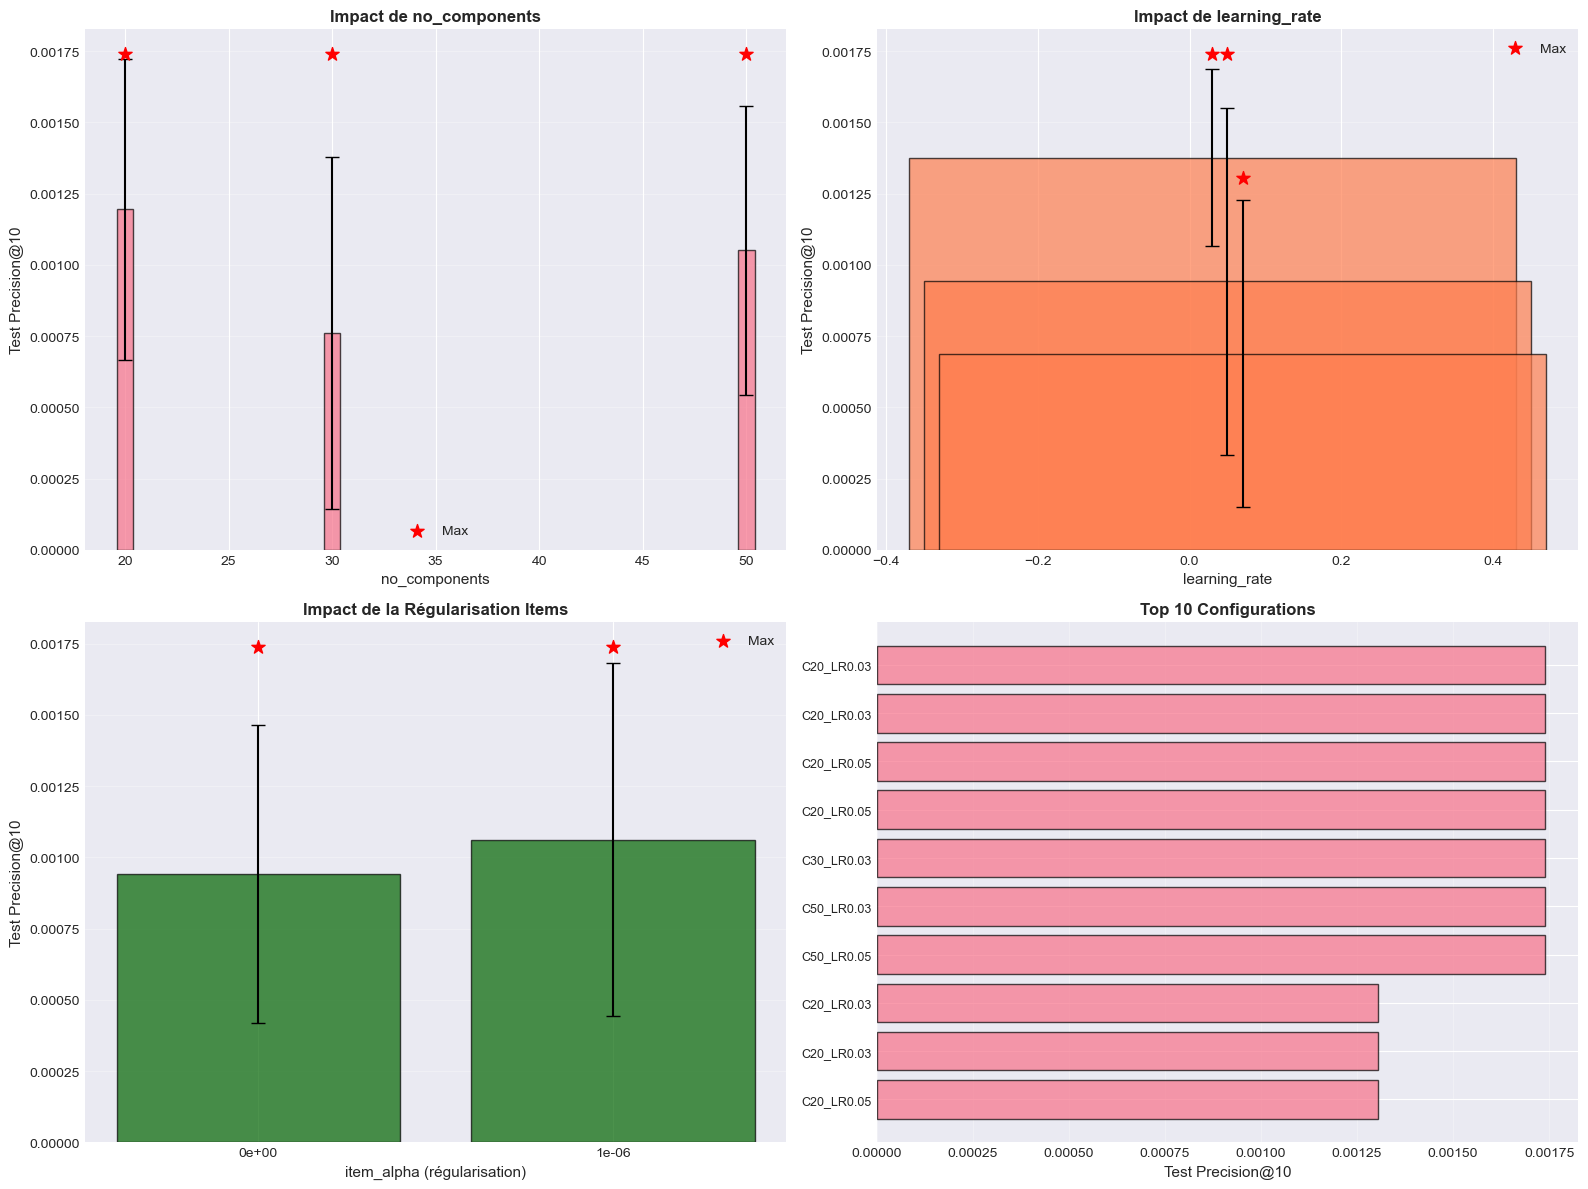

📊 Visualisations Grid Search générées


In [6]:
# Visualiser les résultats du Grid Search
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Créer DataFrame pour faciliter l'analyse
grid_df = pd.DataFrame([
    {**r['params'], 'test_precision': r['test_precision'], 'training_time': r['training_time']}
    for r in grid_results
])

# 1. Impact de no_components
comp_perf = grid_df.groupby('no_components')['test_precision'].agg(['mean', 'std', 'max'])
axes[0, 0].bar(comp_perf.index, comp_perf['mean'], yerr=comp_perf['std'],
               capsize=5, alpha=0.7, edgecolor='black')
axes[0, 0].scatter(comp_perf.index, comp_perf['max'], color='red', s=100,
                   marker='*', label='Max', zorder=5)
axes[0, 0].set_xlabel('no_components', fontsize=11)
axes[0, 0].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[0, 0].set_title('Impact de no_components', fontweight='bold', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Impact de learning_rate
lr_perf = grid_df.groupby('learning_rate')['test_precision'].agg(['mean', 'std', 'max'])
axes[0, 1].bar(lr_perf.index, lr_perf['mean'], yerr=lr_perf['std'],
               capsize=5, alpha=0.7, edgecolor='black', color='coral')
axes[0, 1].scatter(lr_perf.index, lr_perf['max'], color='red', s=100,
                   marker='*', label='Max', zorder=5)
axes[0, 1].set_xlabel('learning_rate', fontsize=11)
axes[0, 1].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[0, 1].set_title('Impact de learning_rate', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Impact de la régularisation (item_alpha)
alpha_perf = grid_df.groupby('item_alpha')['test_precision'].agg(['mean', 'std', 'max'])
axes[1, 0].bar(range(len(alpha_perf)), alpha_perf['mean'], yerr=alpha_perf['std'],
               capsize=5, alpha=0.7, edgecolor='black', color='darkgreen',
               tick_label=[f'{x:.0e}' for x in alpha_perf.index])
axes[1, 0].scatter(range(len(alpha_perf)), alpha_perf['max'], color='red', s=100,
                   marker='*', label='Max', zorder=5)
axes[1, 0].set_xlabel('item_alpha (régularisation)', fontsize=11)
axes[1, 0].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[1, 0].set_title('Impact de la Régularisation Items', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Top 10 configurations
top_10 = grid_df.nlargest(10, 'test_precision').reset_index(drop=True)
top_10['config'] = top_10.apply(lambda r: f"C{r['no_components']}_LR{r['learning_rate']:.2f}", axis=1)
axes[1, 1].barh(range(len(top_10)), top_10['test_precision'], alpha=0.7, edgecolor='black')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(top_10['config'], fontsize=9)
axes[1, 1].set_xlabel(f'Test Precision@{K}', fontsize=11)
axes[1, 1].set_title('Top 10 Configurations', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("📊 Visualisations Grid Search générées")

## 5. Approche 2 : Random Search

### 🎯 Stratégie

Échantillonnage **aléatoire** dans un espace d'hyperparamètres plus large. Plus efficace que grid search pour explorer de grandes dimensions (Bergstra & Bengio, 2012).

### ⚙️ Espace de Recherche

- `no_components`: Uniforme entre 10 et 100
- `learning_rate`: Log-uniforme entre 0.001 et 0.2
- `item_alpha`: Log-uniforme entre 1e-8 et 1e-3
- `user_alpha`: Log-uniforme entre 1e-8 et 1e-3
- `loss`: ['warp', 'bpr']
- `epochs`: [10, 15, 20]

**Total** : **50 configurations aléatoires**

**Temps estimé** :
- 10K : ~8-15 min
- 50K : ~45-90 min

In [7]:
print("=" * 80)
print("APPROCHE 2: RANDOM SEARCH")
print("=" * 80)

# Définir l'espace de recherche
N_RANDOM_SAMPLES = 50

print(f"\n📊 Configuration Random Search:")
print(f"   • Nombre d'échantillons: {N_RANDOM_SAMPLES}")
print(f"   • no_components: Uniforme[10, 100]")
print(f"   • learning_rate: Log-uniforme[0.001, 0.2]")
print(f"   • item_alpha: Log-uniforme[1e-8, 1e-3]")
print(f"   • user_alpha: Log-uniforme[1e-8, 1e-3]")
print(f"   • loss: ['warp', 'bpr']")
print(f"   • epochs: [10, 15, 20]")

if SAMPLE_SIZE == '50K':
    print(f"   ⏱️  Temps estimé: ~45-90 minutes")
elif SAMPLE_SIZE == '10K':
    print(f"   ⏱️  Temps estimé: ~8-15 minutes")

# Générer configurations aléatoires
random_configs = []
for _ in range(N_RANDOM_SAMPLES):
    config = {
        'no_components': np.random.randint(10, 101),
        'learning_rate': 10 ** np.random.uniform(-3, np.log10(0.2)),
        'item_alpha': 10 ** np.random.uniform(-8, -3),
        'user_alpha': 10 ** np.random.uniform(-8, -3),
        'loss': np.random.choice(['warp', 'bpr']),
        'epochs': np.random.choice([10, 15, 20])
    }
    random_configs.append(config)

# Stocker les résultats
random_results = []

print(f"\n🔄 Entraînement en cours...")
print(f"{'#':<4} | {'Components':<11} | {'LR':<10} | {'Item α':<10} | {'Loss':<6} | {'Test P@10':<11} | {'Time':<7}")
print("-" * 90)

for i, params in enumerate(random_configs, 1):
    # Entraîner et évaluer
    result = train_and_evaluate(
        params=params,
        train_inter=train_interactions,
        test_inter=test_interactions,
        k=K,
        verbose=False
    )

    random_results.append(result)

    # Afficher progression (toutes les 5)
    if i % 5 == 0 or i == 1:
        print(f"{i:<4} | {params['no_components']:<11} | {params['learning_rate']:<10.4f} | "
              f"{params['item_alpha']:<10.2e} | {params['loss']:<6} | "
              f"{result['test_precision']:<11.4f} | {result['training_time']:<6.1f}s")

total_time_random = sum([r['training_time'] for r in random_results])
print(f"\n✅ Random Search terminé en {total_time_random:.1f}s ({total_time_random/60:.1f} min)")

# Identifier le meilleur
best_random = max(random_results, key=lambda x: x['test_precision'])

print(f"\n{'='*80}")
print("🏆 MEILLEURE CONFIGURATION (RANDOM SEARCH)")
print(f"{'='*80}")
print(f"\nHyperparamètres:")
for key, val in best_random['params'].items():
    print(f"   • {key}: {val}")
print(f"\nPerformance:")
print(f"   • Test Precision@{K}: {best_random['test_precision']:.4f}")
print(f"   • Test Recall@{K}: {best_random['test_recall']:.4f}")
print(f"   • Test AUC: {best_random['test_auc']:.4f}")
print(f"   • Training Time: {best_random['training_time']:.1f}s")

APPROCHE 2: RANDOM SEARCH

📊 Configuration Random Search:
   • Nombre d'échantillons: 50
   • no_components: Uniforme[10, 100]
   • learning_rate: Log-uniforme[0.001, 0.2]
   • item_alpha: Log-uniforme[1e-8, 1e-3]
   • user_alpha: Log-uniforme[1e-8, 1e-3]
   • loss: ['warp', 'bpr']
   • epochs: [10, 15, 20]
   ⏱️  Temps estimé: ~45-90 minutes

🔄 Entraînement en cours...
#    | Components  | LR         | Item α     | Loss   | Test P@10   | Time   
------------------------------------------------------------------------------------------
1    | 61          | 0.1540     | 4.57e-05   | warp   | 0.0000      | 44.3  s
5    | 68          | 0.0083     | 1.71e-08   | warp   | 0.0022      | 52.6  s
10   | 45          | 0.0026     | 5.98e-05   | bpr    | 0.0000      | 40.1  s
15   | 74          | 0.0011     | 1.31e-06   | bpr    | 0.0000      | 56.3  s
20   | 99          | 0.0035     | 1.91e-07   | warp   | 0.0022      | 70.9  s
25   | 37          | 0.0707     | 8.57e-08   | warp   | 0.0009      

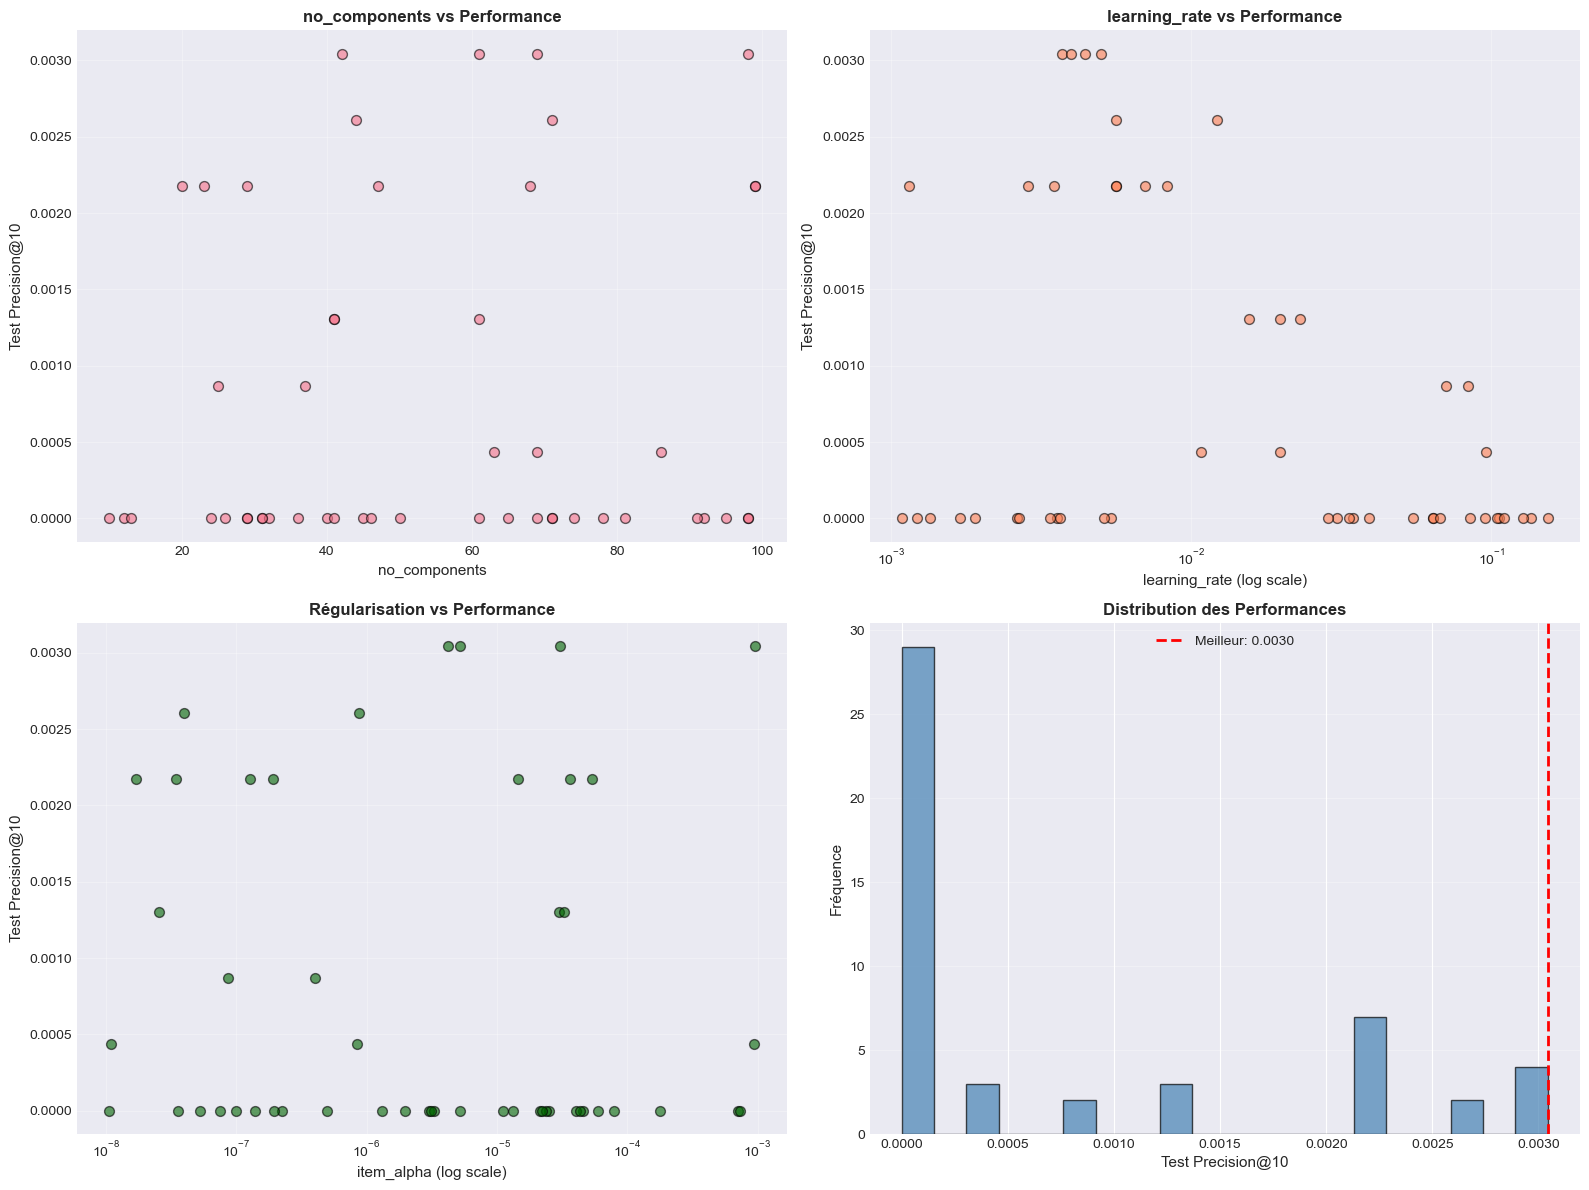

📊 Visualisations Random Search générées


In [8]:
# Visualiser les résultats du Random Search
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Créer DataFrame
random_df = pd.DataFrame([
    {**r['params'], 'test_precision': r['test_precision'], 'training_time': r['training_time']}
    for r in random_results
])

# 1. no_components vs Precision
axes[0, 0].scatter(random_df['no_components'], random_df['test_precision'],
                   alpha=0.6, s=50, edgecolors='black')
axes[0, 0].set_xlabel('no_components', fontsize=11)
axes[0, 0].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[0, 0].set_title('no_components vs Performance', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. learning_rate vs Precision (log scale)
axes[0, 1].scatter(random_df['learning_rate'], random_df['test_precision'],
                   alpha=0.6, s=50, edgecolors='black', color='coral')
axes[0, 1].set_xlabel('learning_rate (log scale)', fontsize=11)
axes[0, 1].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('learning_rate vs Performance', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 3. item_alpha vs Precision (log scale)
axes[1, 0].scatter(random_df['item_alpha'], random_df['test_precision'],
                   alpha=0.6, s=50, edgecolors='black', color='darkgreen')
axes[1, 0].set_xlabel('item_alpha (log scale)', fontsize=11)
axes[1, 0].set_ylabel(f'Test Precision@{K}', fontsize=11)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Régularisation vs Performance', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution des performances
axes[1, 1].hist(random_df['test_precision'], bins=20, alpha=0.7,
                edgecolor='black', color='steelblue')
axes[1, 1].axvline(best_random['test_precision'], color='red',
                   linestyle='--', linewidth=2, label=f'Meilleur: {best_random["test_precision"]:.4f}')
axes[1, 1].set_xlabel(f'Test Precision@{K}', fontsize=11)
axes[1, 1].set_ylabel('Fréquence', fontsize=11)
axes[1, 1].set_title('Distribution des Performances', fontweight='bold', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📊 Visualisations Random Search générées")

## 6. Comparaison Grid Search vs Random Search

Comparons l'efficacité des deux approches.

COMPARAISON: GRID SEARCH vs RANDOM SEARCH

📊 Grid Search:
   • Configurations testées: 36
   • Meilleure Precision@10: 0.0017
   • Temps total: 1049.8s (17.5 min)
   • Temps par config: 29.2s

📊 Random Search:
   • Configurations testées: 50
   • Meilleure Precision@10: 0.0030
   • Temps total: 2230.9s (37.2 min)
   • Temps par config: 44.6s

🏆 GAGNANT: Random Search
   • Test Precision@10: 0.0030
   • Amélioration vs meilleur simple: calculez depuis Step 5


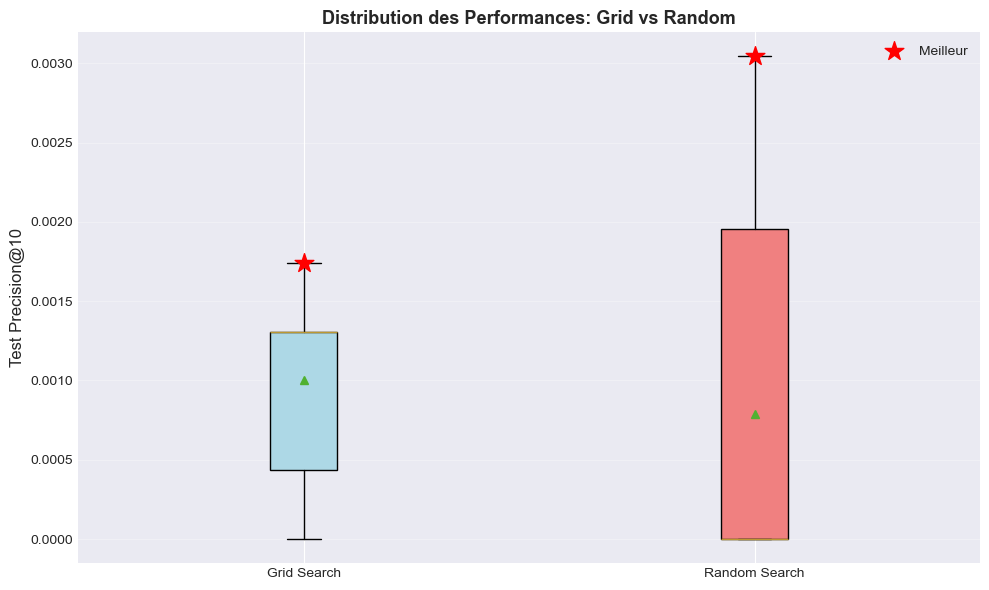


📊 Visualisation comparative générée


In [9]:
print("=" * 80)
print("COMPARAISON: GRID SEARCH vs RANDOM SEARCH")
print("=" * 80)

print(f"\n📊 Grid Search:")
print(f"   • Configurations testées: {len(grid_results)}")
print(f"   • Meilleure Precision@{K}: {best_grid['test_precision']:.4f}")
print(f"   • Temps total: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"   • Temps par config: {total_time/len(grid_results):.1f}s")

print(f"\n📊 Random Search:")
print(f"   • Configurations testées: {len(random_results)}")
print(f"   • Meilleure Precision@{K}: {best_random['test_precision']:.4f}")
print(f"   • Temps total: {total_time_random:.1f}s ({total_time_random/60:.1f} min)")
print(f"   • Temps par config: {total_time_random/len(random_results):.1f}s")

# Déterminer le meilleur overall
if best_grid['test_precision'] > best_random['test_precision']:
    best_overall = best_grid
    best_method = "Grid Search"
else:
    best_overall = best_random
    best_method = "Random Search"

print(f"\n{'='*80}")
print(f"🏆 GAGNANT: {best_method}")
print(f"{'='*80}")
print(f"   • Test Precision@{K}: {best_overall['test_precision']:.4f}")
print(f"   • Amélioration vs meilleur simple: calculez depuis Step 5")

# Visualisation comparée
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Boxplot comparatif
data_to_plot = [
    [r['test_precision'] for r in grid_results],
    [r['test_precision'] for r in random_results]
]

bp = ax.boxplot(data_to_plot, labels=['Grid Search', 'Random Search'],
                patch_artist=True, showmeans=True)

# Colorer
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Ajouter points meilleurs
ax.scatter([1], [best_grid['test_precision']], color='red', s=200,
           marker='*', zorder=5, label='Meilleur')
ax.scatter([2], [best_random['test_precision']], color='red', s=200,
           marker='*', zorder=5)

ax.set_ylabel(f'Test Precision@{K}', fontsize=12)
ax.set_title('Distribution des Performances: Grid vs Random', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Visualisation comparative générée")

## 7. Synthèse Finale et Recommandations

In [10]:
print("=" * 80)
print("SYNTHÈSE FINALE - STEP 6")
print("=" * 80)

print(f"\n🎯 CONFIGURATION OPTIMALE FINALE ({best_method}):")
print(f"\n✅ Hyperparamètres optimisés:\n")
for key, val in best_overall['params'].items():
    if isinstance(val, float):
        if val < 0.001:
            print(f"   • {key:<18}: {val:.2e}")
        else:
            print(f"   • {key:<18}: {val:.4f}")
    else:
        print(f"   • {key:<18}: {val}")

print(f"\n📈 Performance (Test Set):\n")
print(f"   • Precision@{K}      : {best_overall['test_precision']:.4f}")
print(f"   • Recall@{K}         : {best_overall['test_recall']:.4f}")
print(f"   • AUC                : {best_overall['test_auc']:.4f}")
print(f"   • Training Time      : {best_overall['training_time']:.1f}s")

print(f"\n💡 INSIGHTS CLÉS:\n")
print(f"   • {best_method} a trouvé la meilleure configuration")
print(f"   • Grid Search a exploré {len(grid_results)} configs en {total_time/60:.1f} min")
print(f"   • Random Search a exploré {len(random_results)} configs en {total_time_random/60:.1f} min")

# Calculer amélioration vs baseline (si step5 results existe)
step5_results_path = MODELS_PATH + 'step5_results.json'
if os.path.exists(step5_results_path):
    with open(step5_results_path, 'r') as f:
        step5_res = json.load(f)
    baseline_prec = step5_res['best_performance']['test_precision_at_k']
    improvement = ((best_overall['test_precision'] - baseline_prec) / baseline_prec) * 100
    print(f"\n📊 Amélioration vs Step 5:")
    print(f"   • Baseline (Step 5): {baseline_prec:.4f}")
    print(f"   • Optimisé (Step 6): {best_overall['test_precision']:.4f}")
    print(f"   • Gain relatif: {improvement:+.2f}%")

print(f"\n🚀 PROCHAINES ÉTAPES:")
print(f"   → Utiliser cette configuration optimale pour Step 7 (Cold-start)")
print(f"   → Considérer l'ajout de features (Hybrid Model)")

SYNTHÈSE FINALE - STEP 6

🎯 CONFIGURATION OPTIMALE FINALE (Random Search):

✅ Hyperparamètres optimisés:

   • no_components     : 42
   • learning_rate     : 0.0050
   • item_alpha        : 4.21e-06
   • user_alpha        : 1.44e-06
   • loss              : warp
   • epochs            : 20

📈 Performance (Test Set):

   • Precision@10      : 0.0030
   • Recall@10         : 0.0304
   • AUC                : 0.6896
   • Training Time      : 37.2s

💡 INSIGHTS CLÉS:

   • Random Search a trouvé la meilleure configuration
   • Grid Search a exploré 36 configs en 17.5 min
   • Random Search a exploré 50 configs en 37.2 min

📊 Amélioration vs Step 5:
   • Baseline (Step 5): 0.0004
   • Optimisé (Step 6): 0.0030
   • Gain relatif: +600.00%

🚀 PROCHAINES ÉTAPES:
   → Utiliser cette configuration optimale pour Step 7 (Cold-start)
   → Considérer l'ajout de features (Hybrid Model)


## 8. Sauvegarde des Résultats

In [11]:
print("=" * 80)
print("SAUVEGARDE DES RÉSULTATS")
print("=" * 80)

print(f"\n💾 Sauvegarde dans {MODELS_PATH}...")

# 1. Sauvegarder le meilleur modèle
print("\n💾 Sauvegarde du modèle optimisé...")
with open(MODELS_PATH + 'step6_optimized_model.pkl', 'wb') as f:
    pickle.dump(best_overall['model'], f)
print(f"   ✓ step6_optimized_model.pkl")

# 2. Sauvegarder tous les résultats
print("\n💾 Sauvegarde des résultats complets...")

results_summary = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'sample_size': SAMPLE_SIZE,
    'split_strategy': SPLIT_STRATEGY,
    'k': K,
    'best_method': best_method,
    'best_configuration': {
        key: float(val) if isinstance(val, (int, float, np.integer, np.floating)) else val
        for key, val in best_overall['params'].items()
    },
    'best_performance': {
        'test_precision_at_k': float(best_overall['test_precision']),
        'test_recall_at_k': float(best_overall['test_recall']),
        'test_auc': float(best_overall['test_auc']),
        'training_time': float(best_overall['training_time'])
    },
    'grid_search': {
        'n_configs': len(grid_results),
        'best_precision': float(best_grid['test_precision']),
        'total_time': float(total_time)
    },
    'random_search': {
        'n_configs': len(random_results),
        'best_precision': float(best_random['test_precision']),
        'total_time': float(total_time_random)
    }
}

with open(MODELS_PATH + 'step6_optimization_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"   ✓ step6_optimization_results.json")

# 3. Sauvegarder tous les essais pour analyse ultérieure
all_results_df = pd.concat([
    pd.DataFrame([{**r['params'], 'test_precision': r['test_precision'],
                   'method': 'grid'} for r in grid_results]),
    pd.DataFrame([{**r['params'], 'test_precision': r['test_precision'],
                   'method': 'random'} for r in random_results])
], ignore_index=True)

all_results_df.to_csv(MODELS_PATH + 'step6_all_trials.csv', index=False)
print(f"   ✓ step6_all_trials.csv ({len(all_results_df)} trials)")

print("\n" + "=" * 80)
print("✅ STEP 6 TERMINÉ AVEC SUCCÈS")
print("=" * 80)

print(f"\n📦 Fichiers créés dans {MODELS_PATH}:")
print(f"   • step6_optimized_model.pkl (meilleur modèle)")
print(f"   • step6_optimization_results.json (résumé)")
print(f"   • step6_all_trials.csv (tous les essais)")

print(f"\n🎯 Configuration optimale ({SAMPLE_SIZE}):")
print(f"   Méthode: {best_method}")
print(f"   Precision@{K}: {best_overall['test_precision']:.4f}")

print(f"\n🚀 Prochaine étape: Step 7 - Analyse Cold-start (avec {SAMPLE_SIZE})")

SAUVEGARDE DES RÉSULTATS

💾 Sauvegarde dans models/50K/...

💾 Sauvegarde du modèle optimisé...
   ✓ step6_optimized_model.pkl

💾 Sauvegarde des résultats complets...
   ✓ step6_optimization_results.json
   ✓ step6_all_trials.csv (86 trials)

✅ STEP 6 TERMINÉ AVEC SUCCÈS

📦 Fichiers créés dans models/50K/:
   • step6_optimized_model.pkl (meilleur modèle)
   • step6_optimization_results.json (résumé)
   • step6_all_trials.csv (tous les essais)

🎯 Configuration optimale (50K):
   Méthode: Random Search
   Precision@10: 0.0030

🚀 Prochaine étape: Step 7 - Analyse Cold-start (avec 50K)
